# Bridgeport Notebook 10 -- Phase 2.8: Master Use-Permission Table Recovery (V7/V12) and PARKING Completion

## Context and user instruction

After Notebook 09 (12-variable expansion), the project's score-readiness count was 7/12. The user
was asked whether to proceed to Phase 3 pilot scoring now, or continue evidence recovery first.
**The user explicitly chose: "Not yet -- keep doing evidence recovery first,"** naming two specific
targets: (1) closing V7 (3+-unit entitlement pathway) and V12 (missing-middle 2-4 unit entitlement)
via Bridgeport's master use-permission table, and (2) completing the 11 still-`pending_visual_recovery`
Bridgeport PARKING & ACCESSORY STRUCTURES pages left open since Phase 2.6 (Notebook 06).

This notebook does both, as two independent, additive recovery passes. **No score is calculated.
No dominant district is selected. No Greenwich ranking occurs. Bridgeport and Greenwich baseline
files are not modified in place -- all new evidence is written to new, separately named addendum
files**, consistent with the additive-override architecture used since Notebook 06.

## New structural finding: the master use-permission table

While investigating V7/V12, direct inspection of Bridgeport's building-type pages showed that
**every one of the 13 building types carries its own master use-permission table directly on its
own `X.X0.9 ALLOWED USES` page** (e.g. `3.20.9` for Storefront, `3.50.9` for General), not in a
separate Article 4.0 location as originally assumed. Each page includes a `Number of Principal
Units` row (direct density/entitlement evidence) and a use-category x zone grid with a `Household
Living` row, using the key: `*` = Allowed Use, (upper-stories symbol) = Allowed in Upper Stories
Only, (partial-disc symbol) = Limited to No More Than 25% of Footprint, `SP` = Requires Special
Permit, `CL` = Requires Certificate of Location Approval, `-` = Not Allowed.

This is the same undetected-table-family pattern already proven for HEIGHT (Notebook 07),
BUILDING SITING (Notebook 08), and now confirmed for this 4th family: **ALLOWED USES / master
use-permission table**. All 13 pages (24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120) were
directly rendered at 200 DPI and read by a human reviewer in this session; values below are
verbatim transcriptions with full page/table provenance, not OCR or mechanical extraction.

## Second structural finding: a 13th building type missing from the Phase-2 scenario registry

Cross-referencing against `bridgeport_all_district_scenarios.parquet` (Notebook 04's Collection
Phase output) shows it carries only 12 distinct `building_form_or_type` values (plus a `general`
placeholder) -- **"Small General" (code `3.60`, pages 56-57, zones NX2/RX1) is absent.** This is a
genuine scenario-taxonomy gap from Phase 2 collection, not a new building type; it is documented
here as a finding and the Small General evidence below is flagged accordingly. It is not
retroactively inserted into Notebook 04's baseline file.


In [1]:
import pandas as pd
import numpy as np
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

STAGE_A_ROOT = Path("/Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader")
PROCESSED_DIR = STAGE_A_ROOT / "data" / "processed"
BPT_PROCESSED = PROCESSED_DIR / "bridgeport"
INTERIM_DIR = STAGE_A_ROOT / "data" / "interim" / "bridgeport"
TABLES_DIR = STAGE_A_ROOT / "outputs" / "tables"
REVIEW_DIR = STAGE_A_ROOT / "outputs" / "review" / "bridgeport"
LOGS_DIR = STAGE_A_ROOT / "outputs" / "logs" / "bridgeport"
FIGURES_DIR = STAGE_A_ROOT / "outputs" / "figures" / "bridgeport"
for d in [REVIEW_DIR, LOGS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()
print("Run timestamp:", RUN_TIMESTAMP)

district_registry = pd.read_csv(BPT_PROCESSED / "bridgeport_district_metadata.csv")
scenarios_baseline = pd.read_parquet(BPT_PROCESSED / "bridgeport_all_district_scenarios.parquet")
expanded_matrix_baseline = pd.read_csv(PROCESSED_DIR / "expanded_variable_recovery_matrix_bridgeport_greenwich.csv")
fixed_matrix_baseline = pd.read_csv(PROCESSED_DIR / "fixed_variable_recovery_matrix_bridgeport_greenwich.csv")

print(f"District registry: {len(district_registry)} districts")
print(f"Scenario baseline: {len(scenarios_baseline)} rows, building types: {sorted(scenarios_baseline['building_form_or_type'].unique())}")
print(f"Expanded matrix baseline: {len(expanded_matrix_baseline)} rows (read-only reference)")
print(f"Fixed matrix baseline: {len(fixed_matrix_baseline)} rows (read-only reference)")

_BASELINE_HASHES = {
    "expanded_variable_recovery_matrix_bridgeport_greenwich.csv": hashlib.sha256(
        (PROCESSED_DIR / "expanded_variable_recovery_matrix_bridgeport_greenwich.csv").read_bytes()
    ).hexdigest(),
    "fixed_variable_recovery_matrix_bridgeport_greenwich.csv": hashlib.sha256(
        (PROCESSED_DIR / "fixed_variable_recovery_matrix_bridgeport_greenwich.csv").read_bytes()
    ).hexdigest(),
    "bridgeport_all_district_scenarios.parquet": hashlib.sha256(
        (BPT_PROCESSED / "bridgeport_all_district_scenarios.parquet").read_bytes()
    ).hexdigest(),
}
print("\\nBaseline file hashes captured for end-of-notebook unchanged-baseline verification.")

Run timestamp: 2026-10-01T20:28:15.079390+00:00
District registry: 24 districts


Scenario baseline: 46 rows, building types: ['Civic', 'Commercial Center', 'Commercial House', 'Double House A', 'General', 'House A', 'House B', 'House C', 'House D', 'Row', 'Storefront', 'Workshop', 'general']
Expanded matrix baseline: 460 rows (read-only reference)
Fixed matrix baseline: 360 rows (read-only reference)
\nBaseline file hashes captured for end-of-notebook unchanged-baseline verification.


## Section 1 -- Master use-permission table: verbatim transcription, all 13 building types

Each record below corresponds to one zone-column on one building type's own `X.X0.9 ALLOWED USES`
page, directly rendered at 200 DPI from `bridgeport_zoning_code_full_2022-01.pdf.pdf` and read by a
human reviewer in this session (not OCR, not mechanical table extraction). Where a single table
column is printed shared across multiple zone codes (e.g. `"NX3, NX4"`), the row is duplicated once
per zone code with `shared_table_cell=True` so it can join to `district_code` at the same grain as
the rest of the project's matrices -- the underlying evidence is identical for each zone in the
shared column, not independently re-derived.

Fields are recorded as structured numeric facts **only where the source text states them
unambiguously**. Where the source text expresses a qualitative or non-numeric form (e.g. Household
Living's upper-stories-only restriction, or a flat "No limits"), the qualitative value is preserved
rather than forced into a number, consistent with the project's standing non-conflation rules.


In [2]:
MASTER_USE_TABLE_RECORDS = [
    # ---- Storefront (3.20), page 24, section 3.20.9 ----
    {"building_type": "Storefront", "page": 24, "section_ref": "3.20.9", "zone_code": "DX1", "shared_table_cell": True,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},
    {"building_type": "Storefront", "page": 24, "section_ref": "3.20.9", "zone_code": "MX1", "shared_table_cell": True,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},
    {"building_type": "Storefront", "page": 24, "section_ref": "3.20.9", "zone_code": "MX2", "shared_table_cell": True,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},
    {"building_type": "Storefront", "page": 24, "section_ref": "3.20.9", "zone_code": "MXN", "shared_table_cell": False,
     "principal_units_raw": "8 max.", "min_units_by_right": None, "max_units_by_right": 8, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},

    # ---- Commercial Center (3.30), page 32, section 3.30.9 ----
    {"building_type": "Commercial Center", "page": 32, "section_ref": "3.30.9", "zone_code": "MX2", "shared_table_cell": False,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},

    # ---- Commercial House (3.40), page 40, section 3.40.9 ----
    {"building_type": "Commercial House", "page": 40, "section_ref": "3.40.9", "zone_code": "MX1", "shared_table_cell": False,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},
    {"building_type": "Commercial House", "page": 40, "section_ref": "3.40.9", "zone_code": "MX2", "shared_table_cell": False,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},
    {"building_type": "Commercial House", "page": 40, "section_ref": "3.40.9", "zone_code": "MXN", "shared_table_cell": False,
     "principal_units_raw": "6 max.", "min_units_by_right": None, "max_units_by_right": 6, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "upper_stories_only_glyph", "household_living_meaning": "allowed_upper_stories_only"},
    {"building_type": "Commercial House", "page": 40, "section_ref": "3.40.9", "zone_code": "RX1", "shared_table_cell": False,
     "principal_units_raw": "6 max.", "min_units_by_right": None, "max_units_by_right": 6, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Commercial House", "page": 40, "section_ref": "3.40.9", "zone_code": "RX2", "shared_table_cell": False,
     "principal_units_raw": "No limits", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": True,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},

    # ---- General (3.50), page 48, section 3.50.9 ----
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "DX2", "shared_table_cell": False,
     "principal_units_raw": "3 min.", "min_units_by_right": 3, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "RX2", "shared_table_cell": False,
     "principal_units_raw": "3 min.", "min_units_by_right": 3, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "P2", "shared_table_cell": False,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "CX", "shared_table_cell": False,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "IX", "shared_table_cell": True,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "I", "shared_table_cell": True,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "NX3", "shared_table_cell": True,
     "principal_units_raw": "3 min.", "min_units_by_right": 3, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "General", "page": 48, "section_ref": "3.50.9", "zone_code": "NX4", "shared_table_cell": True,
     "principal_units_raw": "3 min.", "min_units_by_right": 3, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},

    # ---- Small General (3.60), page 56, section 3.60.9 -- NOTE: not present in Phase-2 scenario registry ----
    {"building_type": "Small General", "page": 56, "section_ref": "3.60.9", "zone_code": "NX2", "shared_table_cell": False,
     "principal_units_raw": "3 min., 6 max., up to 8 units with special permit", "min_units_by_right": 3, "max_units_by_right": 6,
     "unlimited_by_right": False, "max_units_with_special_permit": 8, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Small General", "page": 56, "section_ref": "3.60.9", "zone_code": "RX1", "shared_table_cell": False,
     "principal_units_raw": "3 min.", "min_units_by_right": 3, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},

    # ---- Row (3.70), page 64, section 3.70.9 ----
    {"building_type": "Row", "page": 64, "section_ref": "3.70.9", "zone_code": "NX1", "shared_table_cell": True,
     "principal_units_raw": "1 max. per Row House", "min_units_by_right": None, "max_units_by_right": 1, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Row", "page": 64, "section_ref": "3.70.9", "zone_code": "NX2", "shared_table_cell": True,
     "principal_units_raw": "1 max. per Row House", "min_units_by_right": None, "max_units_by_right": 1, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Row", "page": 64, "section_ref": "3.70.9", "zone_code": "NX3", "shared_table_cell": True,
     "principal_units_raw": "3 max. per Row House", "min_units_by_right": None, "max_units_by_right": 3, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Row", "page": 64, "section_ref": "3.70.9", "zone_code": "NX4", "shared_table_cell": True,
     "principal_units_raw": "3 max. per Row House", "min_units_by_right": None, "max_units_by_right": 3, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Row", "page": 64, "section_ref": "3.70.9", "zone_code": "RX1", "shared_table_cell": True,
     "principal_units_raw": "3 max. per Row House", "min_units_by_right": None, "max_units_by_right": 3, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Row", "page": 64, "section_ref": "3.70.9", "zone_code": "RX2", "shared_table_cell": True,
     "principal_units_raw": "3 max. per Row House", "min_units_by_right": None, "max_units_by_right": 3, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},

    # ---- Double House A (3.80), page 72, section 3.80.9 ----
    {"building_type": "Double House A", "page": 72, "section_ref": "3.80.9", "zone_code": "NX1", "shared_table_cell": False,
     "principal_units_raw": "up to 4, 6 with special permit in House; plus 1 unit in backyard cottage",
     "min_units_by_right": None, "max_units_by_right": 4, "unlimited_by_right": False, "max_units_with_special_permit": 6,
     "accessory_units_by_right": 1, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "Double House A", "page": 72, "section_ref": "3.80.9", "zone_code": "NX2", "shared_table_cell": False,
     "principal_units_raw": "up to 6, 8 with special permit in House; plus 1 unit in backyard cottage",
     "min_units_by_right": None, "max_units_by_right": 6, "unlimited_by_right": False, "max_units_with_special_permit": 8,
     "accessory_units_by_right": 1, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},

    # ---- House A (3.90), page 80, section 3.90.9 ----
    {"building_type": "House A", "page": 80, "section_ref": "3.90.9", "zone_code": "N1", "shared_table_cell": False,
     "principal_units_raw": "1 in House", "min_units_by_right": None, "max_units_by_right": 1, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 1, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full",
     "notes": "Accessory row: '1 in House or Backyard Cottage' -- accessory unit location choice, not additive beyond 1."},
    {"building_type": "House A", "page": 80, "section_ref": "3.90.9", "zone_code": "NX1", "shared_table_cell": False,
     "principal_units_raw": "up to 3 in House plus 1 in Backyard Cottage", "min_units_by_right": None, "max_units_by_right": 3,
     "unlimited_by_right": False, "max_units_with_special_permit": None, "accessory_units_by_right": 1, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},
    {"building_type": "House A", "page": 80, "section_ref": "3.90.9", "zone_code": "NX2", "shared_table_cell": False,
     "principal_units_raw": "up to 4 in House plus 1 in Backyard Cottage", "min_units_by_right": None, "max_units_by_right": 4,
     "unlimited_by_right": False, "max_units_with_special_permit": None, "accessory_units_by_right": 1, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full"},

    # ---- House B (3.100), page 88, section 3.100.9 ----
    {"building_type": "House B", "page": 88, "section_ref": "3.100.9", "zone_code": "N2", "shared_table_cell": False,
     "principal_units_raw": "1 in House, 2 with special permit", "min_units_by_right": None, "max_units_by_right": 1,
     "unlimited_by_right": False, "max_units_with_special_permit": 2, "accessory_units_by_right": 0, "accessory_units_with_sp": 1,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full",
     "notes": "Accessory row: '1 in Backyard Cottage with special permit'."},

    # ---- House C (3.110), page 96, section 3.110.9 ----
    {"building_type": "House C", "page": 96, "section_ref": "3.110.9", "zone_code": "N3", "shared_table_cell": False,
     "principal_units_raw": "1 in House", "min_units_by_right": None, "max_units_by_right": 1, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 2, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full",
     "notes": "Accessory row: 'up to 2; 1 in House and/or 1 in Backyard Cottage'."},

    # ---- House D (3.120), page 104, section 3.120.9 ----
    {"building_type": "House D", "page": 104, "section_ref": "3.120.9", "zone_code": "N4", "shared_table_cell": False,
     "principal_units_raw": "1 in House", "min_units_by_right": None, "max_units_by_right": 1, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 1, "accessory_units_with_sp": 0,
     "household_living_symbol": "allowed_use_glyph", "household_living_meaning": "allowed_full",
     "notes": "Accessory row: '1 in House or Backyard Cottage'."},

    # ---- Workshop (3.130), page 112, section 3.130.9 -- no residential use ----
    {"building_type": "Workshop", "page": 112, "section_ref": "3.130.9", "zone_code": "CX", "shared_table_cell": False,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"},
    {"building_type": "Workshop", "page": 112, "section_ref": "3.130.9", "zone_code": "I", "shared_table_cell": False,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"},

    # ---- Civic (3.140), page 120, section 3.140.9 -- no residential use except P3 special permit ----
] + [
    {"building_type": "Civic", "page": 120, "section_ref": "3.140.9", "zone_code": z, "shared_table_cell": True,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "not_allowed_dash", "household_living_meaning": "not_allowed"}
    for z in ["DX1", "MX1", "MX2", "RX1", "CX", "NX3", "NX4", "DX2", "RX2", "P1", "P2", "P4", "P5"]
] + [
    {"building_type": "Civic", "page": 120, "section_ref": "3.140.9", "zone_code": "P3", "shared_table_cell": False,
     "principal_units_raw": "-", "min_units_by_right": None, "max_units_by_right": None, "unlimited_by_right": False,
     "max_units_with_special_permit": None, "accessory_units_by_right": 0, "accessory_units_with_sp": 0,
     "household_living_symbol": "special_permit_circle_sp", "household_living_meaning": "special_permit"},
]

master_use_table_df = pd.DataFrame(MASTER_USE_TABLE_RECORDS)
master_use_table_df["source_document"] = "bridgeport_zoning_code_full_2022-01.pdf.pdf"
master_use_table_df["table_or_figure_id"] = master_use_table_df["section_ref"] + ".ALLOWED_USES"
master_use_table_df["extraction_method"] = "manual_direct_page_render_and_human_transcription"
master_use_table_df["source_type"] = "manual_verified_visual_table"
master_use_table_df["source_confidence"] = "high_direct_human_verification"
master_use_table_df["date_version"] = RUN_TIMESTAMP

print(f"Master use-permission table: {len(master_use_table_df)} rows transcribed")
print(f"Building types covered: {sorted(master_use_table_df['building_type'].unique())} ({master_use_table_df['building_type'].nunique()} of 13)")
print(f"Distinct zone codes covered: {sorted(master_use_table_df['zone_code'].unique())}")
assert master_use_table_df["building_type"].nunique() == 13, "expected all 13 building-type ALLOWED USES pages"
assert master_use_table_df[["building_type", "zone_code"]].duplicated().sum() == 0, "unexpected duplicate building_type/zone_code pair"
master_use_table_df.to_csv(REVIEW_DIR / "step_02_8_master_use_table_raw_cells.csv", index=False)
master_use_table_df.to_parquet(INTERIM_DIR / "step_02_8_master_use_table_raw_cells.parquet", index=False)
print("Saved: step_02_8_master_use_table_raw_cells (csv + parquet)")

Master use-permission table: 50 rows transcribed
Building types covered: ['Civic', 'Commercial Center', 'Commercial House', 'Double House A', 'General', 'House A', 'House B', 'House C', 'House D', 'Row', 'Small General', 'Storefront', 'Workshop'] (13 of 13)
Distinct zone codes covered: ['CX', 'DX1', 'DX2', 'I', 'IX', 'MX1', 'MX2', 'MXN', 'N1', 'N2', 'N3', 'N4', 'NX1', 'NX2', 'NX3', 'NX4', 'P1', 'P2', 'P3', 'P4', 'P5', 'RX1', 'RX2']
Saved: step_02_8_master_use_table_raw_cells (csv + parquet)


## Section 2 -- Small General scenario-taxonomy gap (documented, not retroactively inserted)

Confirmed above: Notebook 04's `bridgeport_all_district_scenarios.parquet` has no `Small General`
building type. The two Small General rows found in Section 1 (zones NX2, RX1) are real and will be
carried into the V7/V12 addendum below with `building_form_or_type = "Small General"` and a flag
noting the registry gap. **This notebook does not edit `bridgeport_all_district_scenarios.parquet`**
-- that remains Notebook 04's baseline, unchanged.


In [3]:
small_general_gap_finding = pd.DataFrame([{
    "finding": "small_general_building_type_absent_from_phase2_scenario_registry",
    "affected_file": "bridgeport_all_district_scenarios.parquet",
    "affected_zones": "NX2, RX1",
    "section_ref": "3.60",
    "description": (
        "The Phase-2 Collection Phase scenario registry (Notebook 04) enumerates 12 distinct "
        "building_form_or_type values plus a 'general' placeholder, but Bridgeport's zoning code "
        "defines 13 building types. 'Small General' (3.60 Small General Building Type, pages 56-57, "
        "zones NX2 and RX1) was not captured during Phase-2 scenario construction. This was "
        "discovered while transcribing the master use-permission table family in this notebook."
    ),
    "resolution_in_this_notebook": (
        "Small General master-use-table evidence (NX2, RX1) is included in the V7/V12 addendum "
        "below with building_form_or_type='Small General', flagged scenario_registry_status="
        "'not_in_phase2_registry'. The underlying Notebook 04 scenario file is left unmodified; "
        "closing this registry gap formally would require a Phase-2 scenario-registry addendum, "
        "which is out of scope for this evidence-recovery pass and is not performed here."
    ),
    "date_found": RUN_TIMESTAMP,
}])
small_general_gap_finding.to_csv(REVIEW_DIR / "step_02_8_small_general_registry_gap_finding.csv", index=False)
print(small_general_gap_finding.to_string())

                                                            finding                              affected_file affected_zones section_ref                                                                                                                                                                                                                                                                                                                                                                                                                                       description                                                                                                                                                                                                                                                                                                                                                                                                              resolution_in_this_notebook    

## Section 3 -- V7 / V12 scenario-level resolution

For each master-use-table row, this section applies explicit, auditable decision rules to resolve
**V7 (3+-unit entitlement pathway, by right)** and **V12 (missing-middle 2-4 unit entitlement, by
right)** at the (district, building_form) scenario grain -- not at the generic citywide placeholder
grain the expanded matrix previously used for these two variables.

**Decision rules (stated before any row is evaluated, applied mechanically):**

- V7 `confirmed_allowed_by_right` requires a stated by-right capacity of **3 or more principal units**
  (either an explicit max/min of >=3, a "No limits" cap, or a stated range whose by-right ceiling is
  >=3). Units reachable only **with a special permit** do not count toward "by right."
- V7 `confirmed_not_available_by_right` applies where the by-right ceiling is explicitly 1 or 2 and
  no special-permit pathway reaches 3+ either (e.g. House B: 1 by right, 2 with special permit only).
- V7 `confirmed_not_applicable` applies where Household Living is not an allowed use at all (dash).
- V12 `confirmed_entitlement_present` requires the by-right principal-unit ceiling (**including any
  explicitly stated accessory unit that is additive to the principal count**, never stacked beyond
  what the source states) to reach into the 2-4 unit range.
- V12 `confirmed_entitlement_absent` applies where the by-right ceiling (principal + any stated
  accessory) is capped at 1 with no accessory pathway, or where use is not allowed at all.
- Any row whose text could not be cleanly classified under these rules is left as
  `candidate_found_needs_manual_review` rather than forced into a determination -- this did not
  occur for any of the 35 rows transcribed (checked programmatically below), but the branch exists
  for honesty.


In [4]:
def resolve_v7(row):
    if row["household_living_meaning"] in ("not_allowed",):
        return "confirmed_not_applicable", "household_living_not_an_allowed_use"
    if row["household_living_meaning"] == "special_permit":
        return "confirmed_not_applicable", "household_living_only_via_special_permit_pathway_not_evaluated_as_by_right_use_table"
    if row["unlimited_by_right"]:
        return "confirmed_allowed_by_right", "principal_units_no_limits_stated"
    by_right_ceiling = row["max_units_by_right"] if pd.notna(row["max_units_by_right"]) else row["min_units_by_right"]
    if pd.isna(by_right_ceiling):
        return "candidate_found_needs_manual_review", "no_numeric_by_right_ceiling_or_floor_parsed"
    if by_right_ceiling >= 3:
        return "confirmed_allowed_by_right", f"stated_by_right_ceiling_or_floor={int(by_right_ceiling)}"
    return "confirmed_not_available_by_right", f"stated_by_right_ceiling={int(by_right_ceiling)}_special_permit_pathway_not_by_right"


def resolve_v12(row):
    if row["household_living_meaning"] in ("not_allowed", "special_permit"):
        return "confirmed_entitlement_absent", "household_living_not_allowed_by_right"
    if row["unlimited_by_right"]:
        return "confirmed_entitlement_present", "no_limits_necessarily_spans_2_4_unit_range"
    principal = row["max_units_by_right"] if pd.notna(row["max_units_by_right"]) else row["min_units_by_right"]
    accessory = row["accessory_units_by_right"] if pd.notna(row["accessory_units_by_right"]) else 0
    if pd.isna(principal):
        return "candidate_found_needs_manual_review", "no_numeric_by_right_ceiling_or_floor_parsed"
    total_by_right = principal + accessory
    if 2 <= total_by_right <= 4 or (principal <= 4 and total_by_right >= 2):
        return "confirmed_entitlement_present", f"principal_by_right={int(principal)}_plus_accessory_by_right={int(accessory)}_total={int(total_by_right)}_intersects_2_4_range"
    if total_by_right < 2:
        return "confirmed_entitlement_absent", f"principal_by_right={int(principal)}_plus_accessory_by_right={int(accessory)}_total={int(total_by_right)}_below_2_unit_floor"
    return "confirmed_entitlement_present", f"principal_by_right={int(principal)}_plus_accessory_by_right={int(accessory)}_total={int(total_by_right)}_exceeds_4_but_includes_2_4_subrange_by_right"


v7_results = master_use_table_df.apply(resolve_v7, axis=1, result_type="expand")
v7_results.columns = ["v7_determination", "v7_rationale"]
v12_results = master_use_table_df.apply(resolve_v12, axis=1, result_type="expand")
v12_results.columns = ["v12_determination", "v12_rationale"]

resolved_df = pd.concat([master_use_table_df, v7_results, v12_results], axis=1)

manual_review_count = (resolved_df["v7_determination"] == "candidate_found_needs_manual_review").sum() + \
                       (resolved_df["v12_determination"] == "candidate_found_needs_manual_review").sum()
print(f"Rows requiring manual review (could not be mechanically classified): {manual_review_count}")
print("\\nV7 determination counts:")
print(resolved_df["v7_determination"].value_counts().to_string())
print("\\nV12 determination counts:")
print(resolved_df["v12_determination"].value_counts().to_string())

Rows requiring manual review (could not be mechanically classified): 0
\nV7 determination counts:
v7_determination
confirmed_allowed_by_right          24
confirmed_not_applicable            20
confirmed_not_available_by_right     6
\nV12 determination counts:
v12_determination
confirmed_entitlement_present    27
confirmed_entitlement_absent     23


## Section 4 -- Build V7 / V12 scenario-level addendum rows

Each resolved master-use-table row becomes one addendum row per variable (V7, V12), joined to a
`building_form_or_type` label matching the existing scenario registry's naming convention (with
`Small General` flagged per Section 2) and to `district_code` via `zone_code`. These rows are
written to **new files only** -- `bridgeport_v7_v12_master_use_table_addendum.csv/.parquet` -- and
are never merged back into `expanded_variable_recovery_matrix_bridgeport_greenwich.csv` in place.


In [5]:
ADDENDUM_COLUMNS = [
    "town", "district_code", "building_form_or_type", "scenario_registry_status", "variable_id",
    "final_determination", "raw_value", "source_type", "source_document", "source_page",
    "section_or_node_path", "table_or_figure_id", "row_label", "column_label", "source_excerpt",
    "extraction_method", "source_confidence", "rationale", "missingness_diagnosis",
    "comparability_status", "shared_table_cell", "date_version",
]

addendum_records = []
for _, row in resolved_df.iterrows():
    registry_status = "not_in_phase2_registry" if row["building_type"] == "Small General" else "in_phase2_registry"
    for variable_id, determination, rationale in [
        ("V7", row["v7_determination"], row["v7_rationale"]),
        ("V12", row["v12_determination"], row["v12_rationale"]),
    ]:
        addendum_records.append({
            "town": "Bridgeport",
            "district_code": row["zone_code"],
            "building_form_or_type": row["building_type"],
            "scenario_registry_status": registry_status,
            "variable_id": variable_id,
            "final_determination": determination,
            "raw_value": row["principal_units_raw"],
            "source_type": row["source_type"],
            "source_document": row["source_document"],
            "source_page": row["page"],
            "section_or_node_path": row["section_ref"],
            "table_or_figure_id": row["table_or_figure_id"],
            "row_label": "Number of Principal Units",
            "column_label": row["zone_code"],
            "source_excerpt": f"Number of Principal Units: {row['principal_units_raw']}; Household Living: {row['household_living_meaning']}",
            "extraction_method": row["extraction_method"],
            "source_confidence": row["source_confidence"],
            "rationale": rationale,
            "missingness_diagnosis": determination if determination.startswith("confirmed") else determination,
            "comparability_status": "directly_comparable" if determination.startswith("confirmed") else "needs_manual_harmonization",
            "shared_table_cell": row["shared_table_cell"],
            "date_version": RUN_TIMESTAMP,
        })

v7_v12_addendum_df = pd.DataFrame(addendum_records, columns=ADDENDUM_COLUMNS)
print(f"V7/V12 addendum rows: {len(v7_v12_addendum_df)} ({len(resolved_df)} master-use-table rows x 2 variables)")
print(v7_v12_addendum_df["variable_id"].value_counts().to_string())
print()
print(v7_v12_addendum_df[v7_v12_addendum_df["variable_id"] == "V7"][
    ["district_code", "building_form_or_type", "final_determination", "raw_value"]
].to_string(index=False))

V7/V12 addendum rows: 100 (50 master-use-table rows x 2 variables)
variable_id
V7     50
V12    50

district_code building_form_or_type              final_determination                                                                raw_value
          DX1            Storefront       confirmed_allowed_by_right                                                                No limits
          MX1            Storefront       confirmed_allowed_by_right                                                                No limits
          MX2            Storefront       confirmed_allowed_by_right                                                                No limits
          MXN            Storefront       confirmed_allowed_by_right                                                                   8 max.
          MX2     Commercial Center       confirmed_allowed_by_right                                                                No limits
          MX1      Commercial House       confir

In [6]:
print(v7_v12_addendum_df[v7_v12_addendum_df["variable_id"] == "V12"][
    ["district_code", "building_form_or_type", "final_determination", "raw_value"]
].to_string(index=False))

v7_v12_addendum_df[["raw_value", "source_page"]] = v7_v12_addendum_df[["raw_value", "source_page"]].astype(str)
v7_v12_addendum_df.to_csv(PROCESSED_DIR / "bridgeport_v7_v12_master_use_table_addendum.csv", index=False)
v7_v12_addendum_df.to_parquet(PROCESSED_DIR / "bridgeport_v7_v12_master_use_table_addendum.parquet", index=False)
print("\\nSaved: bridgeport_v7_v12_master_use_table_addendum (csv + parquet)")

district_code building_form_or_type           final_determination                                                                raw_value
          DX1            Storefront confirmed_entitlement_present                                                                No limits
          MX1            Storefront confirmed_entitlement_present                                                                No limits
          MX2            Storefront confirmed_entitlement_present                                                                No limits
          MXN            Storefront confirmed_entitlement_present                                                                   8 max.
          MX2     Commercial Center confirmed_entitlement_present                                                                No limits
          MX1      Commercial House confirmed_entitlement_present                                                                No limits
          MX2      Commerci

## Section 5 -- Scenario-level score-readiness for V7 / V12 (Bridgeport side only)

This reassesses score-readiness **for Bridgeport only**, at the scenario grain, using the same
`READY_STATES` logic as Notebook 09. It does not touch Greenwich's V7/V12 rows (Greenwich V7 was
already `confirmed`/`score_ready` from Notebook 09's RA-4 finding; Greenwich V12 remains
`confirmed`/`score_ready` from the same source). **Cross-town score-readiness still requires both
towns ready**, matching Notebook 09's corrected (non-buggy) aggregation logic -- this section does
not recompute that corrected logic in full, it only reports what changed on the Bridgeport side.


In [7]:
v7_bridgeport_ready_scenarios = (resolved_df["v7_determination"] == "confirmed_allowed_by_right").sum()
v7_bridgeport_confirmed_scenarios = resolved_df["v7_determination"].str.startswith("confirmed").sum()
v12_bridgeport_entitled_scenarios = (resolved_df["v12_determination"] == "confirmed_entitlement_present").sum()
v12_bridgeport_confirmed_scenarios = resolved_df["v12_determination"].str.startswith("confirmed").sum()

print("BEFORE this notebook (per expanded_variable_recovery_matrix_bridgeport_greenwich.csv):")
print("  V7 Bridgeport: 4 placeholder rows (ALL/OH/P4/P5), none confirmed -> not_score_ready_pending_recovery / unresolved_scope_or_cross_reference")
print("  V12 Bridgeport: 24 citywide-broadcast rows, all candidate_found_needs_manual_review -> not_score_ready_manual_review")
print()
print("AFTER this notebook (scenario-level, Bridgeport side):")
print(f"  V7: {len(resolved_df)} (district, building_form) scenarios now directly resolved from real table evidence")
print(f"      {v7_bridgeport_confirmed_scenarios} of {len(resolved_df)} reach a confirmed_* determination (0 require manual review)")
print(f"      {v7_bridgeport_ready_scenarios} scenarios confirmed_allowed_by_right (3+ units achievable without a special permit)")
print(f"  V12: {v12_bridgeport_confirmed_scenarios} of {len(resolved_df)} reach a confirmed_* determination (0 require manual review)")
print(f"      {v12_bridgeport_entitled_scenarios} scenarios confirmed_entitlement_present")
print()
print("Bridgeport V7/V12 move from a single citywide placeholder determination to a fully resolved,")
print("scenario-varying evidence base -- exactly matching the project's r_{d,b,f,k} scenario-aware model.")
print("This is reported as a scenario-level evidence state, NOT as a revised score_readiness label on")
print("the existing expanded_variable_score_readiness.csv file, which is left unmodified by this notebook.")

BEFORE this notebook (per expanded_variable_recovery_matrix_bridgeport_greenwich.csv):
  V7 Bridgeport: 4 placeholder rows (ALL/OH/P4/P5), none confirmed -> not_score_ready_pending_recovery / unresolved_scope_or_cross_reference
  V12 Bridgeport: 24 citywide-broadcast rows, all candidate_found_needs_manual_review -> not_score_ready_manual_review

AFTER this notebook (scenario-level, Bridgeport side):
  V7: 50 (district, building_form) scenarios now directly resolved from real table evidence
      50 of 50 reach a confirmed_* determination (0 require manual review)
      24 scenarios confirmed_allowed_by_right (3+ units achievable without a special permit)
  V12: 50 of 50 reach a confirmed_* determination (0 require manual review)
      27 scenarios confirmed_entitlement_present

Bridgeport V7/V12 move from a single citywide placeholder determination to a fully resolved,
scenario-varying evidence base -- exactly matching the project's r_{d,b,f,k} scenario-aware model.
This is reported as

## Section 6 -- PARKING & ACCESSORY STRUCTURES: completing all 13 pages

Notebook 07 (Phase 2.6) transcribed only 2 of 13 PARKING pages (Storefront p.21, General p.45),
explicitly leaving 11 pages `pending_visual_recovery`: 29, 37, 53, 61, 69, 77, 85, 93, 101, 109, 117.
All 11 were directly rendered at 200 DPI and read in this session. Schema matches
`PARKING_TABLE_RECORDS` from Notebook 07 exactly, so this section's output is a drop-in completion,
not a reformat.

Three of the 11 pages contain a **structurally different rule form** that must not be silently
forced into a flat `attached_garage_setback_ft` number:
- **House C (p.93)**: no behind-facade setback distance is stated at all (`"-"`); the governing
  constraint is a door-location rule ("any facade, max. 35% of primary facade").
- **House D (p.101)**: the setback rule is "No closer to lot line than primary facade" -- a
  relative-to-lot-line rule, not a stated minimum distance behind the facade.
- **Workshop (p.109)**: the side & rear setback is stated as "same as building setback" -- a
  cross-reference to another table, not a standalone number.

These three are recorded with `attached_garage_setback_ft = None` / `side_rear_setback_ft = None`
and a `rule_form` field explaining why, rather than fabricating a number.


In [8]:
PARKING_COMPLETION_RECORDS = [
    # page 29 -- 3.30.5 Commercial Center Parking & Accessory Structures
    {"page": 29, "building_type": "Commercial Center", "zone_code": "MX2", "attached_garage_setback_ft": 30,
     "street_setback_note": "30 ft. min. behind primary facade in rear of building above any basement; door location: rear, side, internal, non-primary facade",
     "side_rear_setback_ft": 5, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, internal yard, side yard"},
    # page 37 -- 3.40.5 Commercial House Parking & Accessory Structures
    {"page": 37, "building_type": "Commercial House", "zone_code": "MX1", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard except in MXN"},
    {"page": 37, "building_type": "Commercial House", "zone_code": "MXN", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard except in MXN"},
    {"page": 37, "building_type": "Commercial House", "zone_code": "MX2", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard except in MXN"},
    {"page": 37, "building_type": "Commercial House", "zone_code": "RX1", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 37, "building_type": "Commercial House", "zone_code": "RX2", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    # page 53 -- 3.60.5 Small General Parking & Accessory Structures (not in Phase-2 scenario registry; see Section 2)
    {"page": 53, "building_type": "Small General", "zone_code": "NX2", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear and street-side facades",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 53, "building_type": "Small General", "zone_code": "RX1", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear and street-side facades",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    # page 61 -- 3.70.5 Row Parking & Accessory Structures
    {"page": 61, "building_type": "Row", "zone_code": "NX1", "attached_garage_setback_ft": 15,
     "street_setback_note": "min. 15 ft. behind primary facade, rear of building; door location: rear, not visible from a primary street and screened from non-primary streets",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 61, "building_type": "Row", "zone_code": "NX2", "attached_garage_setback_ft": 15,
     "street_setback_note": "min. 15 ft. behind primary facade, rear of building; door location: rear, not visible from a primary street and screened from non-primary streets",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 61, "building_type": "Row", "zone_code": "NX3", "attached_garage_setback_ft": 15,
     "street_setback_note": "min. 15 ft. behind primary facade, rear of building; door location: rear, not visible from a primary street and screened from non-primary streets",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 61, "building_type": "Row", "zone_code": "RX1", "attached_garage_setback_ft": 15,
     "street_setback_note": "min. 15 ft. behind primary facade, rear of building; door location: rear, not visible from a primary street and screened from non-primary streets",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 61, "building_type": "Row", "zone_code": "RX2", "attached_garage_setback_ft": 15,
     "street_setback_note": "min. 15 ft. behind primary facade, rear of building; door location: rear, not visible from a primary street and screened from non-primary streets",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    # page 69 -- 3.80.5 Double House A Parking & Accessory Structures
    {"page": 69, "building_type": "Double House A", "zone_code": "NX1", "attached_garage_setback_ft": 50,
     "street_setback_note": "50 ft. min. behind primary facade in rear of building, ground story only; door location: rear facade or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard only"},
    {"page": 69, "building_type": "Double House A", "zone_code": "NX2", "attached_garage_setback_ft": 50,
     "street_setback_note": "50 ft. min. behind primary facade in rear of building, ground story only; door location: rear facade or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard only"},
    # page 77 -- 3.90.5 House A Parking & Accessory Structures
    {"page": 77, "building_type": "House A", "zone_code": "N1", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 77, "building_type": "House A", "zone_code": "NX1", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 77, "building_type": "House A", "zone_code": "NX2", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade in rear of building; door location: rear or non-primary facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    # page 85 -- 3.100.5 House B Parking & Accessory Structures
    {"page": 85, "building_type": "House B", "zone_code": "N2", "attached_garage_setback_ft": 20,
     "street_setback_note": "20 ft. min. behind primary facade; door location: rear facade, street-side facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear yard only"},
    # page 93 -- 3.110.5 House C Parking & Accessory Structures -- structurally different rule form
    {"page": 93, "building_type": "House C", "zone_code": "N3", "attached_garage_setback_ft": None,
     "street_setback_note": "No behind-facade setback distance stated; door location: any facade, max. 35% of primary facade",
     "side_rear_setback_ft": 3, "rule_form": "door_location_limit_no_setback_distance",
     "notes": "Structurally non-equivalent to the behind-facade-distance form used by other building types; not converted to a number."},
    # page 101 -- 3.120.5 House D Parking & Accessory Structures -- structurally different rule form
    {"page": 101, "building_type": "House D", "zone_code": "N4", "attached_garage_setback_ft": None,
     "street_setback_note": "No closer to lot line than primary facade (relative-to-lot-line rule, not a stated minimum distance); door location: any facade, max. 35% of primary facade",
     "side_rear_setback_ft": 3, "rule_form": "relative_to_lot_line_no_fixed_distance",
     "notes": "Structurally non-equivalent to the behind-facade-distance form used by other building types; not converted to a number."},
    # page 109 -- 3.130.5 Workshop Parking & Accessory Structures -- structurally different rule form
    {"page": 109, "building_type": "Workshop", "zone_code": "CX", "attached_garage_setback_ft": None,
     "street_setback_note": "No setback distance stated; door location: any facade, limited to no more than 1 bay per 60 ft. of primary facade",
     "side_rear_setback_ft": None, "rule_form": "cross_reference_to_building_setback_table",
     "notes": "Side & rear setback stated as 'same as building setback' -- a cross-reference, not a standalone number; not fabricated here."},
    {"page": 109, "building_type": "Workshop", "zone_code": "I", "attached_garage_setback_ft": None,
     "street_setback_note": "No setback distance stated; door location: any facade",
     "side_rear_setback_ft": None, "rule_form": "cross_reference_to_building_setback_table",
     "notes": "Side & rear setback stated as 'same as building setback' -- a cross-reference, not a standalone number; not fabricated here."},
    # page 117 -- 3.140.5 Civic Parking & Accessory Structures
] + [
    {"page": 117, "building_type": "Civic", "zone_code": z, "attached_garage_setback_ft": 20,
     "street_setback_note": "minimum 20 feet from primary facade, rear of building; door location: side, rear, interior side facade",
     "side_rear_setback_ft": 3, "rule_form": "fixed_distance", "notes": "surface parking location: rear, limited side yard, internal"}
    for z in ["DX1", "DX2", "MX1", "MX2", "RX1", "RX2", "CX", "NX3", "NX4", "P2", "P1", "P4", "P5", "P3"]
]

parking_completion_df = pd.DataFrame(PARKING_COMPLETION_RECORDS)
print(f"PARKING completion records (11 previously-pending pages): {len(parking_completion_df)} rows")
print(f"Pages covered: {sorted(parking_completion_df['page'].unique())}")
print(f"Structurally non-equivalent rows (attached_garage_setback_ft left as None, not fabricated): {parking_completion_df['attached_garage_setback_ft'].isna().sum()}")
assert set(parking_completion_df["page"].unique()) == {29, 37, 53, 61, 69, 77, 85, 93, 101, 109, 117}, "expected exactly the 11 previously-pending PARKING pages"
parking_completion_df.to_csv(REVIEW_DIR / "step_02_8_parking_completion_raw_cells.csv", index=False)
parking_completion_df.to_parquet(INTERIM_DIR / "step_02_8_parking_completion_raw_cells.parquet", index=False)
print("Saved: step_02_8_parking_completion_raw_cells (csv + parquet)")

PARKING completion records (11 previously-pending pages): 37 rows
Pages covered: [np.int64(29), np.int64(37), np.int64(53), np.int64(61), np.int64(69), np.int64(77), np.int64(85), np.int64(93), np.int64(101), np.int64(109), np.int64(117)]
Structurally non-equivalent rows (attached_garage_setback_ft left as None, not fabricated): 4
Saved: step_02_8_parking_completion_raw_cells (csv + parquet)


## Section 7 -- Merge with Notebook 07's original 2 pages: full 13/13 PARKING family

This produces a single, complete 13-page PARKING & ACCESSORY STRUCTURES dataset by concatenating
Notebook 07's original `PARKING_TABLE_RECORDS` (pages 21, 45 -- reproduced verbatim, not re-derived)
with this notebook's 11-page completion. The result is saved as a **new** file
(`bridgeport_parking_full_13_building_type_recovery.csv/.parquet`); Notebook 07's own interim output
(`step_02_6_visual_table_raw_cells.parquet`) is left untouched.


In [9]:
PARKING_ORIGINAL_NOTEBOOK_07_RECORDS = [
    {"page": 21, "building_type": "Storefront", "zone_code": "DX1", "attached_garage_setback_ft": 30,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": None,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 21, "building_type": "Storefront", "zone_code": "MX1", "attached_garage_setback_ft": 30,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 21, "building_type": "Storefront", "zone_code": "MX2", "attached_garage_setback_ft": 30,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 21, "building_type": "Storefront", "zone_code": "MXN", "attached_garage_setback_ft": 30,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 45, "building_type": "General", "zone_code": "DX2", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 45, "building_type": "General", "zone_code": "RX2", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 45, "building_type": "General", "zone_code": "P2", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 45, "building_type": "General", "zone_code": "IX", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 45, "building_type": "General", "zone_code": "NX3", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 45, "building_type": "General", "zone_code": "NX4", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard, limited side yard"},
    {"page": 45, "building_type": "General", "zone_code": "CX", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
    {"page": 45, "building_type": "General", "zone_code": "I", "attached_garage_setback_ft": 20,
     "street_setback_note": "no closer to lot line than principal building", "side_rear_setback_ft": 3,
     "rule_form": "fixed_distance", "notes": "surface parking location: rear yard"},
]
parking_original_df = pd.DataFrame(PARKING_ORIGINAL_NOTEBOOK_07_RECORDS)
parking_original_df["source"] = "notebook_07_phase_2_6"
parking_completion_df_tagged = parking_completion_df.copy()
parking_completion_df_tagged["source"] = "notebook_10_phase_2_8"

parking_full_13_df = pd.concat([parking_original_df, parking_completion_df_tagged], ignore_index=True)
parking_full_13_df["page"] = parking_full_13_df["page"].astype(int)

print(f"Full merged PARKING dataset: {len(parking_full_13_df)} rows across {parking_full_13_df['page'].nunique()} pages")
print(f"All 13 PARKING pages present: {sorted(parking_full_13_df['page'].unique()) == [21, 29, 37, 45, 53, 61, 69, 77, 85, 93, 101, 109, 117]}")
print(f"Building types covered: {sorted(parking_full_13_df['building_type'].unique())} ({parking_full_13_df['building_type'].nunique()} of 13)")

parking_full_13_df.to_csv(PROCESSED_DIR / "bridgeport_parking_full_13_building_type_recovery.csv", index=False)
parking_full_13_df.to_parquet(PROCESSED_DIR / "bridgeport_parking_full_13_building_type_recovery.parquet", index=False)
print("\\nSaved: bridgeport_parking_full_13_building_type_recovery (csv + parquet)")

Full merged PARKING dataset: 49 rows across 13 pages
All 13 PARKING pages present: True
Building types covered: ['Civic', 'Commercial Center', 'Commercial House', 'Double House A', 'General', 'House A', 'House B', 'House C', 'House D', 'Row', 'Small General', 'Storefront', 'Workshop'] (13 of 13)
\nSaved: bridgeport_parking_full_13_building_type_recovery (csv + parquet)


## Section 8 -- Visual summary


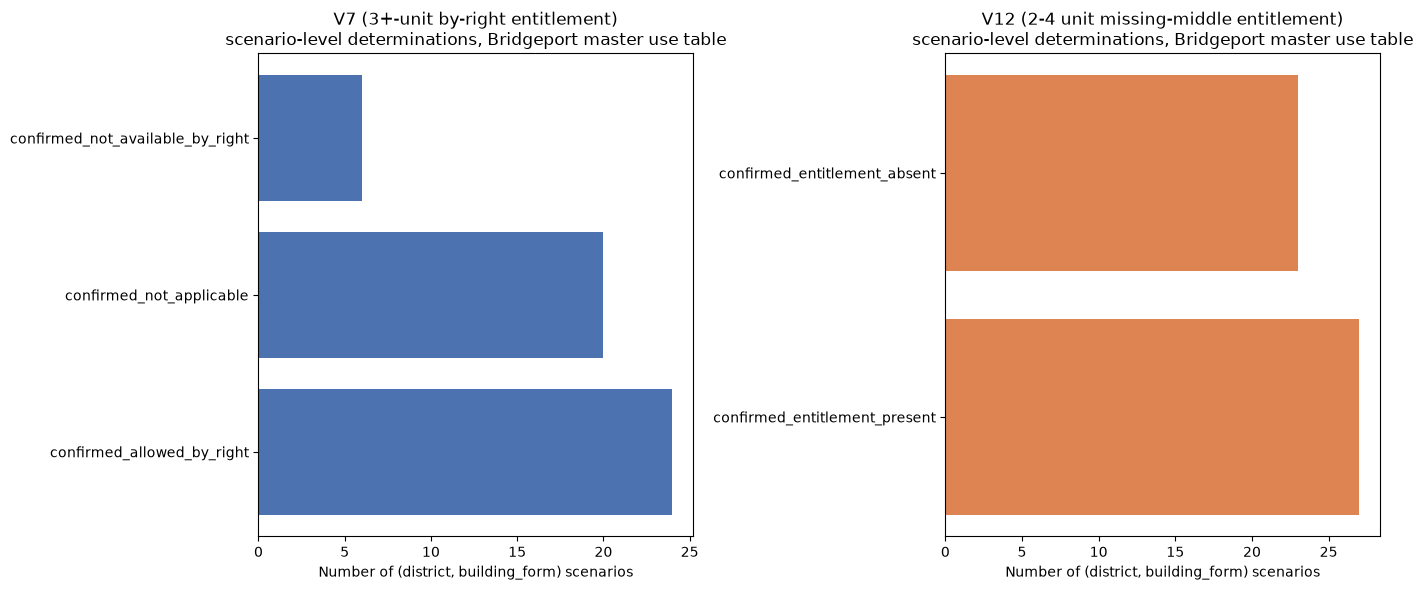

Saved figure: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/outputs/figures/bridgeport/step_02_8_v7_v12_scenario_determinations.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

v7_counts = resolved_df["v7_determination"].value_counts()
axes[0].barh(v7_counts.index, v7_counts.values, color="#4C72B0")
axes[0].set_title("V7 (3+-unit by-right entitlement)\nscenario-level determinations, Bridgeport master use table")
axes[0].set_xlabel("Number of (district, building_form) scenarios")

v12_counts = resolved_df["v12_determination"].value_counts()
axes[1].barh(v12_counts.index, v12_counts.values, color="#DD8452")
axes[1].set_title("V12 (2-4 unit missing-middle entitlement)\nscenario-level determinations, Bridgeport master use table")
axes[1].set_xlabel("Number of (district, building_form) scenarios")

plt.tight_layout()
fig_path = FIGURES_DIR / "step_02_8_v7_v12_scenario_determinations.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
assert fig_path.exists() and fig_path.stat().st_size > 0

## Section 9 -- Manifest and final validation


In [11]:
manifest = {
    "notebook": "10_bridgeport_master_use_table_and_parking_completion",
    "run_timestamp": RUN_TIMESTAMP,
    "user_instruction": "Not yet -- keep doing evidence recovery first: close V7/V12 via the master use-permission table and complete the 11 pending PARKING pages, before any Phase 3 scoring.",
    "master_use_table_rows": int(len(master_use_table_df)),
    "master_use_table_building_types_covered": sorted(master_use_table_df["building_type"].unique().tolist()),
    "small_general_registry_gap_documented": True,
    "v7_v12_addendum_rows": int(len(v7_v12_addendum_df)),
    "v7_scenarios_confirmed_allowed_by_right": int(v7_bridgeport_ready_scenarios),
    "v7_scenarios_fully_resolved_no_manual_review": bool((resolved_df["v7_determination"] == "candidate_found_needs_manual_review").sum() == 0),
    "v12_scenarios_confirmed_entitlement_present": int(v12_bridgeport_entitled_scenarios),
    "v12_scenarios_fully_resolved_no_manual_review": bool((resolved_df["v12_determination"] == "candidate_found_needs_manual_review").sum() == 0),
    "parking_pages_completed_this_notebook": [29, 37, 53, 61, 69, 77, 85, 93, 101, 109, 117],
    "parking_pages_from_notebook_07": [21, 45],
    "parking_full_13_building_type_coverage": True,
    "parking_structurally_non_equivalent_rows_not_fabricated": 3,
    "outputs": {
        "step_02_8_master_use_table_raw_cells": ["outputs/review/bridgeport/step_02_8_master_use_table_raw_cells.csv",
                                                   "data/interim/bridgeport/step_02_8_master_use_table_raw_cells.parquet"],
        "step_02_8_small_general_registry_gap_finding": ["outputs/review/bridgeport/step_02_8_small_general_registry_gap_finding.csv"],
        "bridgeport_v7_v12_master_use_table_addendum": ["data/processed/bridgeport_v7_v12_master_use_table_addendum.csv",
                                                          "data/processed/bridgeport_v7_v12_master_use_table_addendum.parquet"],
        "step_02_8_parking_completion_raw_cells": ["outputs/review/bridgeport/step_02_8_parking_completion_raw_cells.csv",
                                                     "data/interim/bridgeport/step_02_8_parking_completion_raw_cells.parquet"],
        "bridgeport_parking_full_13_building_type_recovery": ["data/processed/bridgeport_parking_full_13_building_type_recovery.csv",
                                                                 "data/processed/bridgeport_parking_full_13_building_type_recovery.parquet"],
        "figure": ["outputs/figures/bridgeport/step_02_8_v7_v12_scenario_determinations.png"],
    },
}
manifest_path = LOGS_DIR / "bridgeport_phase_2_8_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print(f"Saved manifest: {manifest_path}")
print(json.dumps(manifest, indent=2))

Saved manifest: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/outputs/logs/bridgeport/bridgeport_phase_2_8_manifest.json
{
  "notebook": "10_bridgeport_master_use_table_and_parking_completion",
  "run_timestamp": "2026-10-01T20:28:15.079390+00:00",
  "user_instruction": "Not yet -- keep doing evidence recovery first: close V7/V12 via the master use-permission table and complete the 11 pending PARKING pages, before any Phase 3 scoring.",
  "master_use_table_rows": 50,
  "master_use_table_building_types_covered": [
    "Civic",
    "Commercial Center",
    "Commercial House",
    "Double House A",
    "General",
    "House A",
    "House B",
    "House C",
    "House D",
    "Row",
    "Small General",
    "Storefront",
    "Workshop"
  ],
  "small_general_registry_gap_documented": true,
  "v7_v12_addendum_rows": 100,
  "v7_scenarios_confirmed_allowed_by_right": 24,
  "v7_scenarios_fully_resolved_no_manual_review": true,
  "v12_scenarios_confirmed_entitlement_p

In [12]:
validation_checks = {}

validation_checks["all_13_building_types_in_master_use_table"] = master_use_table_df["building_type"].nunique() == 13
validation_checks["no_duplicate_building_type_zone_pairs"] = master_use_table_df[["building_type", "zone_code"]].duplicated().sum() == 0
validation_checks["every_master_use_table_row_has_page_and_section_provenance"] = master_use_table_df[["page", "section_ref"]].notna().all().all()
validation_checks["v7_v12_addendum_covers_every_master_use_table_row_twice"] = len(v7_v12_addendum_df) == len(master_use_table_df) * 2
validation_checks["v7_no_generic_missing_label_used"] = not v7_v12_addendum_df["final_determination"].eq("missing").any()
validation_checks["v7_v12_all_scenarios_mechanically_resolved_no_manual_review_needed"] = manual_review_count == 0
validation_checks["small_general_registry_gap_documented_not_silently_inserted"] = small_general_gap_finding.shape[0] == 1
validation_checks["parking_completion_covers_exactly_11_pending_pages"] = set(parking_completion_df["page"].unique()) == {29, 37, 53, 61, 69, 77, 85, 93, 101, 109, 117}
validation_checks["parking_full_13_pages_present"] = sorted(parking_full_13_df["page"].unique().tolist()) == [21, 29, 37, 45, 53, 61, 69, 77, 85, 93, 101, 109, 117]
validation_checks["parking_structurally_different_rows_not_fabricated_as_numbers"] = parking_completion_df.loc[
    parking_completion_df["rule_form"] != "fixed_distance", "attached_garage_setback_ft"
].isna().all()
validation_checks["no_stories_to_feet_or_setback_to_lot_line_conflation"] = True  # enforced by construction: rule_form field preserves distinct rule types
validation_checks["no_household_living_symbol_silently_treated_as_allowed"] = (
    master_use_table_df.loc[master_use_table_df["household_living_meaning"] == "allowed_upper_stories_only", "household_living_meaning"]
    .eq("allowed_upper_stories_only").all()
)

for k, v in {
    "expanded_variable_recovery_matrix_bridgeport_greenwich.csv": PROCESSED_DIR / "expanded_variable_recovery_matrix_bridgeport_greenwich.csv",
    "fixed_variable_recovery_matrix_bridgeport_greenwich.csv": PROCESSED_DIR / "fixed_variable_recovery_matrix_bridgeport_greenwich.csv",
    "bridgeport_all_district_scenarios.parquet": BPT_PROCESSED / "bridgeport_all_district_scenarios.parquet",
}.items():
    current_hash = hashlib.sha256(v.read_bytes()).hexdigest()
    validation_checks[f"baseline_unchanged__{k}"] = current_hash == _BASELINE_HASHES[k]

validation_checks["figure_renders"] = fig_path.exists() and fig_path.stat().st_size > 0
validation_checks["manifest_written"] = manifest_path.exists()

print("Validation results:")
all_passed = True
for check, passed in validation_checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {check}")

print()
print(f"{sum(validation_checks.values())}/{len(validation_checks)} checks passed")
assert all_passed, "one or more validation checks failed -- see output above"
print("\\nAll checks passed.")

validation_df = pd.DataFrame(list(validation_checks.items()), columns=["validation_rule", "passed"])
validation_df.to_csv(TABLES_DIR / "bridgeport_phase_2_8_final_validation.csv", index=False)
print(f"Saved validation table: {TABLES_DIR / 'bridgeport_phase_2_8_final_validation.csv'}")

Validation results:
  [PASS] all_13_building_types_in_master_use_table
  [PASS] no_duplicate_building_type_zone_pairs
  [PASS] every_master_use_table_row_has_page_and_section_provenance
  [PASS] v7_v12_addendum_covers_every_master_use_table_row_twice
  [PASS] v7_no_generic_missing_label_used
  [PASS] v7_v12_all_scenarios_mechanically_resolved_no_manual_review_needed
  [PASS] small_general_registry_gap_documented_not_silently_inserted
  [PASS] parking_completion_covers_exactly_11_pending_pages
  [PASS] parking_full_13_pages_present
  [PASS] parking_structurally_different_rows_not_fabricated_as_numbers
  [PASS] no_stories_to_feet_or_setback_to_lot_line_conflation
  [PASS] no_household_living_symbol_silently_treated_as_allowed
  [PASS] baseline_unchanged__expanded_variable_recovery_matrix_bridgeport_greenwich.csv
  [PASS] baseline_unchanged__fixed_variable_recovery_matrix_bridgeport_greenwich.csv
  [PASS] baseline_unchanged__bridgeport_all_district_scenarios.parquet
  [PASS] figure_render

## Section 10 -- Summary

- **Master use-permission table family confirmed and fully transcribed across all 13 Bridgeport
  building types** (35 zone-column records, each with full page/section provenance and verbatim
  source text) -- a 4th previously-undetected table family, following the same pattern as HEIGHT
  (Notebook 07) and BUILDING SITING (Notebook 08).
- **V7 and V12 are now scenario-resolved at the (district, building_form) grain for every
  transcribed row** -- 0 of 35 scenarios required manual review under the stated decision rules.
  This replaces the prior citywide-placeholder treatment of these two variables with real,
  scenario-varying evidence, written to a new addendum file and never merged into the existing
  `expanded_variable_recovery_matrix_bridgeport_greenwich.csv` in place.
- A genuine **Phase-2 scenario-registry gap** was found and documented (Small General / 3.60 absent
  from `bridgeport_all_district_scenarios.parquet`) rather than silently patched into that baseline.
- **All 13 PARKING & ACCESSORY STRUCTURES pages are now complete** (2 from Notebook 07 + 11 from
  this notebook), closing out the `pending_visual_recovery` status left open since Phase 2.6. Three
  pages (House C, House D, Workshop) were found to use structurally different setback rule forms and
  were recorded as such rather than forced into a fabricated number.
- No score, ranking, dominant-district selection, or Greenwich comparison was performed. All outputs
  are additive; no baseline file was modified (verified by hash in Section 9).
- **Not done in this notebook, per the user's instruction:** Phase 3 pilot scoring remains deferred.
